# Branching Pipelines

Branch pipelines are **secondary pipelines** that:
- Originate from the **primary dataframe** or from **Nebula Storage**
- Can be merged back via **join**, **append**, or not at all (**dead-end**)
- Leave the **main flow unchanged** until the merge point

**What you'll learn:**
1. Branch from storage or primary dataframe
2. Join, append, or dead-end merge strategies
3. The `otherwise` parameter for parallel processing paths

In [1]:
import polars as pl

from nebula import TransformerPipeline
from nebula.storage import nebula_storage as ns
from nebula.transformers import (
    AddLiterals,
    Filter,
    RenameColumns,
    SelectColumns,
)

## Sample Data

In [2]:
# Main orders dataframe
orders_df = pl.DataFrame({
    "order_id": [1, 2, 3, 4, 5, 6],
    "customer": ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"],
    "amount": [150.0, 80.0, 320.0, 45.0, 200.0, 95.0],
    "status": ["completed", "pending", "completed", "pending", "completed", "cancelled"],
})

# Customer metadata (for joins)
customers_df = pl.DataFrame({
    "customer": ["Alice", "Bob", "Charlie", "Diana"],
    "tier": ["gold", "silver", "gold", "bronze"],
    "region": ["US", "EU", "US", "APAC"],
})

print("Orders:")
print(orders_df)
print("\nCustomers:")
print(customers_df)

Orders:
shape: (6, 4)
┌──────────┬──────────┬────────┬───────────┐
│ order_id ┆ customer ┆ amount ┆ status    │
│ ---      ┆ ---      ┆ ---    ┆ ---       │
│ i64      ┆ str      ┆ f64    ┆ str       │
╞══════════╪══════════╪════════╪═══════════╡
│ 1        ┆ Alice    ┆ 150.0  ┆ completed │
│ 2        ┆ Bob      ┆ 80.0   ┆ pending   │
│ 3        ┆ Charlie  ┆ 320.0  ┆ completed │
│ 4        ┆ Diana    ┆ 45.0   ┆ pending   │
│ 5        ┆ Eve      ┆ 200.0  ┆ completed │
│ 6        ┆ Frank    ┆ 95.0   ┆ cancelled │
└──────────┴──────────┴────────┴───────────┘

Customers:
shape: (4, 3)
┌──────────┬────────┬────────┐
│ customer ┆ tier   ┆ region │
│ ---      ┆ ---    ┆ ---    │
│ str      ┆ str    ┆ str    │
╞══════════╪════════╪════════╡
│ Alice    ┆ gold   ┆ US     │
│ Bob      ┆ silver ┆ EU     │
│ Charlie  ┆ gold   ┆ US     │
│ Diana    ┆ bronze ┆ APAC   │
└──────────┴────────┴────────┘


---
# Part 1: Branch Pipelines

Branch pipelines are **secondary pipelines** that:
- Originate from the **primary dataframe** or from **Nebula Storage**
- Can be merged back via **join**, **append**, or not at all (**dead-end**)
- Leave the **main flow unchanged** until the merge point

## Branch Input: Where does the data come from?

![Branch Input Options](images/branch_df_input.jpg)

- **With `"storage": key`** — Branch reads from a previously stored dataframe
- **Without `storage`** — Branch gets a copy of the current dataframe

## Branch Output: How is it merged back?

![Branch Output Options](images/branch_df_output.jpg)

| `end` value | Description |
|-------------|-------------|
| `"dead-end"` | Branch result is discarded (useful for side-effects like logging/storing) |
| `"join"` | Branch result is joined to main dataframe (requires `on`, `how`) |
| `"append"` | Branch result is vertically concatenated to main dataframe |

### 1.1 Branch from Storage → Join Back

Process a stored dataframe and join the result to the main flow.

In [3]:
# Store customer metadata for later use
ns.set("customer_metadata", customers_df)

# Pipeline: enrich orders with customer tier
pipe_branch_storage_join = TransformerPipeline(
    [
        # Branch transforms the stored customer data
        SelectColumns(columns=["customer", "tier"]),
        RenameColumns(mapping={"tier": "customer_tier"}),
    ],
    branch={
        "storage": "customer_metadata",  # Input from storage
        "end": "join",                   # Merge via join
        "on": "customer",                # Join key
        "how": "left",                   # Keep all orders
        "skip": False,
    },
    name="Enrich with Customer Tier",
)

pipe_branch_storage_join.show(add_params=True)

2026-03-09 12:37:34,138 | [INFO]: Nebula Storage: setting an object (<class 'polars.dataframe.frame.DataFrame'>) with the key "customer_metadata". 


*** Enrich with Customer Tier *** (2 transformations)
------ BRANCH (from storage: customer_metadata) ------
>> Branch (2 transformations):
     - SelectColumns -> PARAMS: columns=['customer', 'tier']
     - RenameColumns -> PARAMS: mapping={'tier': 'customer_tier'}
<<< Join DFs >>>
  - how: left
  - on: customer


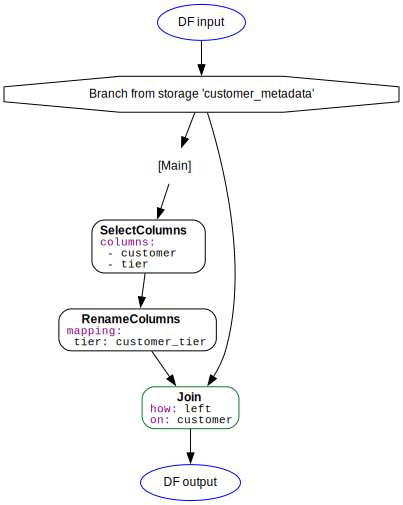

In [4]:
pipe_branch_storage_join.plot(add_params=True)

In [5]:
result = pipe_branch_storage_join.run(orders_df)
result

2026-03-09 12:37:34,926 | [INFO]: Starting pipeline 'Enrich with Customer Tier' 
2026-03-09 12:37:34,926 | [INFO]: Entering branch 
2026-03-09 12:37:34,928 | [INFO]: Running 'SelectColumns' ... 
2026-03-09 12:37:34,938 | [INFO]: Completed 'SelectColumns' in 0.0s 
2026-03-09 12:37:34,939 | [INFO]: Running 'RenameColumns' ... 
2026-03-09 12:37:34,939 | [INFO]: Completed 'RenameColumns' in 0.0s 
2026-03-09 12:37:34,966 | [INFO]: Pipeline 'Enrich with Customer Tier' completed in 0.0s 


order_id,customer,amount,status,customer_tier
i64,str,f64,str,str
1,"""Alice""",150.0,"""completed""","""gold"""
2,"""Bob""",80.0,"""pending""","""silver"""
3,"""Charlie""",320.0,"""completed""","""gold"""
4,"""Diana""",45.0,"""pending""","""bronze"""
5,"""Eve""",200.0,"""completed""",null
6,"""Frank""",95.0,"""cancelled""",null


### 1.2 Branch from Primary DF → Join Back

Fork from the current dataframe, transform it, and join back. Useful for creating derived columns from aggregations.

In [6]:
def calculate_customer_totals(df):
    """Aggregate total spend per customer."""
    return df.group_by("customer").agg(
        pl.col("amount").sum().alias("total_spend")
    )


pipe_branch_primary_join = TransformerPipeline(
    [
        calculate_customer_totals,
    ],
    branch={
        # No "storage" key = branch from current dataframe
        "end": "join",
        "on": "customer",
        "how": "left",
    },
    name="Add Customer Totals",
)

result = pipe_branch_primary_join.run(orders_df)
result

2026-03-09 12:37:34,980 | [INFO]: Starting pipeline 'Add Customer Totals' 
2026-03-09 12:37:34,980 | [INFO]: Entering branch 
2026-03-09 12:37:34,981 | [INFO]: Running 'calculate_customer_totals' ... 
2026-03-09 12:37:34,988 | [INFO]: Completed 'calculate_customer_totals' in 0.0s 
2026-03-09 12:37:34,988 | [INFO]: Pipeline 'Add Customer Totals' completed in 0.0s 


order_id,customer,amount,status,total_spend
i64,str,f64,str,f64
1,"""Alice""",150.0,"""completed""",150.0
2,"""Bob""",80.0,"""pending""",80.0
3,"""Charlie""",320.0,"""completed""",320.0
4,"""Diana""",45.0,"""pending""",45.0
5,"""Eve""",200.0,"""completed""",200.0
6,"""Frank""",95.0,"""cancelled""",95.0


### 1.3 Branch → Append

Process a subset and append it back (vertical concatenation).

In [7]:
pipe_branch_append = TransformerPipeline(
    [
        # Branch: duplicate high-value orders with a flag
        Filter(input_col="amount", perform="keep", operator="ge", value=200),
        AddLiterals(data=[{"alias": "is_duplicate", "value": True}]),
    ],
    branch={
        "end": "append",  # Vertical concatenation
    },
    # Main flow also needs the column for schema compatibility
    otherwise=[
        AddLiterals(data=[{"alias": "is_duplicate", "value": False}]),
    ],
    name="Duplicate High-Value Orders",
)

result = pipe_branch_append.run(orders_df)
print(f"Original: {len(orders_df)} rows, After append: {len(result)} rows")
result.sort("order_id")

2026-03-09 12:37:35,006 | [INFO]: Starting pipeline 'Duplicate High-Value Orders' 
2026-03-09 12:37:35,006 | [INFO]: Entering branch 
2026-03-09 12:37:35,011 | [INFO]: Running 'Filter' ... 
2026-03-09 12:37:35,013 | [INFO]: Completed 'Filter' in 0.0s 
2026-03-09 12:37:35,014 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:37:35,016 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:37:35,016 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:37:35,016 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:37:35,019 | [INFO]: Pipeline 'Duplicate High-Value Orders' completed in 0.0s 


Original: 6 rows, After append: 8 rows


order_id,customer,amount,status,is_duplicate
i64,str,f64,str,bool
1,"""Alice""",150.0,"""completed""",false
2,"""Bob""",80.0,"""pending""",false
3,"""Charlie""",320.0,"""completed""",true
3,"""Charlie""",320.0,"""completed""",false
4,"""Diana""",45.0,"""pending""",false
5,"""Eve""",200.0,"""completed""",true
5,"""Eve""",200.0,"""completed""",false
6,"""Frank""",95.0,"""cancelled""",false


### 1.4 Branch → Dead-End

Process data without merging back. Useful for:
- Storing intermediate results
- Logging/auditing
- Side-effect operations

In [8]:
def store_high_value_for_review(df):
    """Store high-value orders for manual review."""
    ns.set("high_value_review", df)
    print(f"📋 Stored {len(df)} high-value orders for review")
    return df


pipe_branch_deadend = TransformerPipeline(
    [
        Filter(input_col="amount", perform="keep", operator="ge", value=200),
        store_high_value_for_review,
    ],
    branch={
        "end": "dead-end",  # Don't merge back
    },
    name="Archive High-Value Orders",
)

result = pipe_branch_deadend.run(orders_df)
print(f"\nOutput is unchanged ({len(result)} rows):")
result

2026-03-09 12:37:35,036 | [INFO]: Starting pipeline 'Archive High-Value Orders' 
2026-03-09 12:37:35,039 | [INFO]: Entering branch 
2026-03-09 12:37:35,039 | [INFO]: Running 'Filter' ... 
2026-03-09 12:37:35,039 | [INFO]: Completed 'Filter' in 0.0s 
2026-03-09 12:37:35,039 | [INFO]: Running 'store_high_value_for_review' ... 
2026-03-09 12:37:35,039 | [INFO]: Nebula Storage: setting an object (<class 'polars.dataframe.frame.DataFrame'>) with the key "high_value_review". 
2026-03-09 12:37:35,039 | [INFO]: Completed 'store_high_value_for_review' in 0.0s 
2026-03-09 12:37:35,039 | [INFO]: Pipeline 'Archive High-Value Orders' completed in 0.0s 


📋 Stored 2 high-value orders for review

Output is unchanged (6 rows):


order_id,customer,amount,status
i64,str,f64,str
1,"""Alice""",150.0,"""completed"""
2,"""Bob""",80.0,"""pending"""
3,"""Charlie""",320.0,"""completed"""
4,"""Diana""",45.0,"""pending"""
5,"""Eve""",200.0,"""completed"""
6,"""Frank""",95.0,"""cancelled"""


In [9]:
# But the high-value orders were stored separately
print("Stored for review:")
ns.get("high_value_review")

Stored for review:


order_id,customer,amount,status
i64,str,f64,str
3,"""Charlie""",320.0,"""completed"""
5,"""Eve""",200.0,"""completed"""


### 1.5 The `otherwise` Parameter

When using `branch` (without storage) or `apply_to_rows`, you can specify an `otherwise` pipeline that processes the **main dataframe** while the branch processes its fork.

This is useful when both paths need compatible schemas for merging.

In [10]:
pipe_with_otherwise = TransformerPipeline(
    [
        # Branch: mark completed orders
        Filter(input_col="status", perform="keep", operator="eq", value="completed"),
        AddLiterals(data=[{"alias": "processed", "value": "completed_flow"}]),
    ],
    branch={
        "end": "append",
    },
    otherwise=[
        # Main flow: mark non-completed orders
        Filter(input_col="status", perform="remove", operator="eq", value="completed"),
        AddLiterals(data=[{"alias": "processed", "value": "other_flow"}]),
    ],
    name="Parallel Processing Paths",
)

result = pipe_with_otherwise.run(orders_df)
result.sort("order_id")

2026-03-09 12:37:35,081 | [INFO]: Starting pipeline 'Parallel Processing Paths' 
2026-03-09 12:37:35,081 | [INFO]: Entering branch 
2026-03-09 12:37:35,085 | [INFO]: Running 'Filter' ... 
2026-03-09 12:37:35,086 | [INFO]: Completed 'Filter' in 0.0s 
2026-03-09 12:37:35,086 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:37:35,086 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:37:35,086 | [INFO]: Running 'Filter' ... 
2026-03-09 12:37:35,089 | [INFO]: Completed 'Filter' in 0.0s 
2026-03-09 12:37:35,089 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:37:35,089 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:37:35,089 | [INFO]: Pipeline 'Parallel Processing Paths' completed in 0.0s 


order_id,customer,amount,status,processed
i64,str,f64,str,str
1,"""Alice""",150.0,"""completed""","""completed_flow"""
2,"""Bob""",80.0,"""pending""","""other_flow"""
3,"""Charlie""",320.0,"""completed""","""completed_flow"""
4,"""Diana""",45.0,"""pending""","""other_flow"""
5,"""Eve""",200.0,"""completed""","""completed_flow"""
6,"""Frank""",95.0,"""cancelled""","""other_flow"""


---
## Summary

| Config Key | Description |
|------------|-------------|
| `storage` | Key to read input from (omit to use current df) |
| `end` | `"dead-end"`, `"join"`, or `"append"` |
| `on` | Join key(s) (for `end="join"`) |
| `how` | Join type: `"inner"`, `"left"`, `"right"`, `"full"` |
| `left_on` / `right_on` | Different key names for join |
| `suffix` | Suffix for duplicate column names |
| `skip` / `perform` | Conditionally disable the branch |

**Next notebook:** Apply-to-Rows — filter, transform, and merge row subsets